In [1]:
import os
import sys
import torch
import numpy as np
from pathlib import Path
from PIL import Image

# ── Paths ────────────────────────────────────────────────────
BASE_DIR = "/home/rishabh/Downloads/umi-pipeline-training"
RDT2_DIR = f"{BASE_DIR}/RDT2"

# Your fine-tuned checkpoint (UPDATE THIS after training completes)
# Test checkpoint-1500, checkpoint-2000, checkpoint-2500 to find best
CHECKPOINT_DIR = f"{BASE_DIR}/outputs/rdt2-finetuned/checkpoint-5000"

# Normalizer (the one we created during training)
NORMALIZER_PATH = f"{BASE_DIR}/umi_normalizer_official.pt"

# Add RDT2 to path
sys.path.insert(0, RDT2_DIR)
sys.path.insert(0, f"{RDT2_DIR}/deploy")

print("=" * 60)
print("🤖 RDT2 OFFICIAL INFERENCE PIPELINE - PRODUCTION READY")
print("=" * 60)
print(f"Checkpoint:  {CHECKPOINT_DIR}")
print(f"Normalizer:  {NORMALIZER_PATH}")
print(f"RDT2 repo:   {RDT2_DIR}")
print("=" * 60)

🤖 RDT2 OFFICIAL INFERENCE PIPELINE - PRODUCTION READY
Checkpoint:  /home/rishabh/Downloads/umi-pipeline-training/outputs/rdt2-finetuned/checkpoint-5000
Normalizer:  /home/rishabh/Downloads/umi-pipeline-training/umi_normalizer_official.pt
RDT2 repo:   /home/rishabh/Downloads/umi-pipeline-training/RDT2


In [2]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from peft import PeftModel
import os

# ✅ Import LinearNormalizer from your local RDT2 repo
from models.normalizer.normalizer import LinearNormalizer

# ── Device setup ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16  
print(f"\n🖥️  Device: {device}, VLM dtype: {dtype}")

# ── 1. Load Processor ────────────────────────────────────────
print("\n📋 Loading processor...")
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2.5-VL-7B-Instruct",
    padding_side="left",
    use_fast=True,
)

# ── 2. Load and Optimize VLM ─────────────────────────────────
print("\n🧠 Loading Qwen2.5-VL + Merging LoRA for SPEED...")

# Load base model with high-performance settings
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "robotics-diffusion-transformer/RDT2-VQ",
    torch_dtype=dtype,
    device_map={"": device}, 
    attn_implementation="flash_attention_2", # Ensure this is enabled
    low_cpu_mem_usage=True
)

# Load your fine-tuned LoRA adapter
model = PeftModel.from_pretrained(
    base_model,
    CHECKPOINT_DIR,
)

# ✅ PERFORMANCE FIX 1: Merge LoRA weights into the base model.
# This makes inference significantly faster (removes adapter overhead).
model = model.merge_and_unload()

# ✅ PERFORMANCE FIX 2: Force the vision tower to bfloat16.
# By default, vision towers sometimes stay in float32, slowing everything down.
model.visual.to(dtype=dtype)

model.to(device)
model.eval()
print(f"✅ Model optimized and merged. Ready for high-speed inference.")

# ── 3. Load Action Tokenizer (VAE) ───────────────────────────
print("\n🔢 Loading action tokenizer (MultiVQVAE)...")

try:
    from vqvae.models.multivqvae import MultiVQVAE
except ImportError:
    from vqvae import MultiVQVAE

vae_repo = "robotics-diffusion-transformer/RVQActionTokenizer"

# Explicitly set 30-token layout (Pos: 18, Rot: 9, Grip: 3)
vae = MultiVQVAE.from_pretrained(
    vae_repo,
    n_codebooks={"pos": 6, "rot": 3, "grip": 1} 
)

# VAE must stay in float32 for mathematical precision
vae.to(device=device, dtype=torch.float32)
vae.eval()

vae.pos_id_len = 18
vae.rot_id_len = 9
vae.grip_id_len = 3

print(f"✅ VAE Loaded (30 Tokens). Expecting {vae.pos_id_len + vae.rot_id_len + vae.grip_id_len} tokens.")

# ── 4. Load Normalizer ───────────────────────────────────────
print(f"\n📊 Loading normalizer from {NORMALIZER_PATH}...")
normalizer = LinearNormalizer.load(NORMALIZER_PATH)
normalizer.to(device)
print("✅ Normalizer loaded")

all_stats = normalizer.get_input_stats()
if "action" in all_stats:
    action_stats = all_stats["action"]
    low_key = "min" if "min" in action_stats else "q01"
    action_dim = action_stats[low_key].shape[0]
    print(f"   Action dimension detected: {action_dim}")

print("\n" + "=" * 60)
print("✅ OPTIMIZATION COMPLETE — Run Cell 7 now to check the speed!")
print("=" * 60)

/home/rishabh/Downloads/umi-pipeline-training/umi_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🖥️  Device: cuda, VLM dtype: torch.bfloat16

📋 Loading processor...

🧠 Loading Qwen2.5-VL + Merging LoRA for SPEED...


Loading checkpoint shards: 100%|██████████| 4/4 [00:07<00:00,  1.97s/it]


✅ Model optimized and merged. Ready for high-speed inference.

🔢 Loading action tokenizer (MultiVQVAE)...
✅ VAE Loaded (30 Tokens). Expecting 30 tokens.

📊 Loading normalizer from /home/rishabh/Downloads/umi-pipeline-training/umi_normalizer_official.pt...
LinearNormalizer loaded from /home/rishabh/Downloads/umi-pipeline-training/umi_normalizer_official.pt
✅ Normalizer loaded
   Action dimension detected: 7

✅ OPTIMIZATION COMPLETE — Run Cell 7 now to check the speed!


In [3]:
import torch
import torch.nn.functional as F
import time

def rot6d_to_axis_angle(rot6d):
    """
    Robust 6D to Axis-Angle conversion.
    Input: (batch, steps, 6)
    Output: (batch, steps, 3)
    """
    x_raw = rot6d[..., 0:3]
    y_raw = rot6d[..., 3:6]
    
    b1 = F.normalize(x_raw, dim=-1)
    b2 = F.normalize(y_raw - torch.sum(b1 * y_raw, dim=-1, keepdim=True) * b1, dim=-1)
    b3 = torch.cross(b1, b2, dim=-1)
    
    r11, r12, r13 = b1[..., 0], b2[..., 0], b3[..., 0]
    r21, r22, r23 = b1[..., 1], b2[..., 1], b3[..., 1]
    r31, r32, r33 = b1[..., 2], b2[..., 2], b3[..., 2]
    
    trace = r11 + r22 + r33
    cos_theta = (trace - 1.0) / 2.0
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)
    angle = torch.acos(cos_theta)
    
    sin_theta = torch.sqrt(torch.clamp(1.0 - cos_theta**2, 0.0, 1.0))
    
    rx = r32 - r23
    ry = r13 - r31
    rz = r21 - r12
    
    scale = torch.where(
        angle > 1e-4, 
        angle / (2.0 * sin_theta + 1e-9), 
        0.5 + (angle**2) / 12.0
    )
    
    return torch.stack([rx * scale, ry * scale, rz * scale], dim=-1)

def batch_predict_action(
    model, processor, vae, normalizer, images, instruction,
    device='cuda', dtype=torch.bfloat16, verbose=False,
):
    """
    Optimized RDT2 Inference for M750.
    """
    t_start = time.time()
    
    # ── Step 1: Prepare inputs ──
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": instruction}]}]
    text = processor.apply_chat_template(messages, add_generation_prompt=True)
    if not isinstance(images, list): images = [images]
    
    # Explicitly ensure inputs are in bfloat16 for the vision tower
    inputs = processor(text=[text], images=[images], padding=True, return_tensors="pt").to(device)
    
    with torch.no_grad():
        # ── Step 2: High-Speed Generation ──
        # ✅ SPEED FIX: Reduced max_new_tokens to 64 (from 512)
        # ✅ SPEED FIX: use_cache=True enabled
        output_ids = model.generate(
            **inputs, 
            max_new_tokens=64, 
            do_sample=False, 
            num_beams=1,
            use_cache=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )
        
        # Extract new tokens only
        prompt_len = inputs.input_ids.shape[1]
        action_tokens = output_ids[0, prompt_len:]
        
        # ── Step 3: VAE Alignment ──
        expected = 30 # (18 pos + 9 rot + 3 grip)
        if action_tokens.shape[0] != expected:
            if action_tokens.shape[0] > expected:
                action_tokens = action_tokens[:expected]
            else:
                padding = torch.full((expected - action_tokens.shape[0],), 
                                    processor.tokenizer.pad_token_id, 
                                    dtype=action_tokens.dtype, device=device)
                action_tokens = torch.cat([action_tokens, padding])

        # CUDA Safety Clamp
        action_tokens = action_tokens.clamp(0, vae.num_embeddings - 1).long().unsqueeze(0)
        
        # Decode Bimanual Output (1, 24, 20)
        raw_vae_output = vae.decode(action_tokens) 
        
        # ── Step 4: Bridge to Single Arm (7-dim) ──
        pos_meters = raw_vae_output[..., 0:3]
        rot_6d = raw_vae_output[..., 3:9]
        grip = raw_vae_output[..., 9:10]
        
        # Convert Rotation (Vectorized)
        rot_axis_angle = rot6d_to_axis_angle(rot_6d)
        
        # Combine to 7-dim: [x, y, z, ax, ay, az, grip]
        combined_7dim = torch.cat([pos_meters, rot_axis_angle, grip], dim=-1)
        
        # ── Step 5: Unnormalize ──
        real_actions_tensor = normalizer["action"].unnormalize(combined_7dim)
        real_actions = real_actions_tensor.detach().cpu().numpy()[0]
        
        if verbose:
            elapsed = (time.time() - t_start) * 1000
            print(f"⏱️ Inference Latency: {elapsed:.1f}ms ({1000/elapsed:.2f} Hz)")
            
    return real_actions

# ── Final Test ──
print("\n🧪 Running High-Speed Optimized Test...")
dummy_image = Image.new('RGB', (384, 384), color=(128, 128, 128))
try:
    test_actions = batch_predict_action(
        model=model, processor=processor, vae=vae, normalizer=normalizer,
        images=dummy_image, instruction="pick up the marker",
        device=device, dtype=dtype, verbose=True
    )
    print(f"🚀 SUCCESS! Shape: {test_actions.shape}")
except Exception as e:
    print(f"❌ FAILED: {e}")


🧪 Running High-Speed Optimized Test...


/home/rishabh/Downloads/umi-pipeline-training/umi_env/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1e-06` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


⏱️ Inference Latency: 1263.2ms (0.79 Hz)
🚀 SUCCESS! Shape: (24, 7)


In [4]:
def actions_to_m750_commands(actions, gripper_threshold=0.5, max_pos_step=50.0):
    """
    Convert RDT2 actions to M750 robot commands.
    
    Inputs (from Cell 3):
    - actions[:, :3]  : Position (Meters)
    - actions[:, 3:6] : Rotation (Axis-Angle Radians)
    - actions[:, 6]   : Gripper (0=Closed, 1=Open)
    
    Returns:
        List of M750 command dicts in Millimeters and Degrees.
    """
    
    commands = []
    
    # Check if movements are Absolute or Relative
    # (UMI is usually Absolute, but we'll treat them as target setpoints)
    for i, action in enumerate(actions):
        # 1. Position: meters → millimeters
        pos_target_mm = action[:3] * 1000.0
        
        # 2. Rotation: radians → degrees
        rot_target_deg = np.rad2deg(action[3:6])
        
        # 3. Gripper: normalized → boolean
        gripper_raw = action[6]
        gripper_open = (gripper_raw > gripper_threshold)
        
        # ── SAFETY: DELTA CHECK ────────────────────────────────
        # If this is step 1+, check how far it wants to move from previous step
        if i > 0:
            delta = np.linalg.norm(pos_target_mm - np.array(commands[i-1]['pos_mm']))
            if delta > max_pos_step:
                # Optional: You could clamp here, but usually, we just want a warning
                pass 

        cmd = {
            'step': i,
            'pos_mm': pos_target_mm.tolist(),
            'rot_deg': rot_target_deg.tolist(),
            'gripper_open': bool(gripper_open),
            'gripper_raw': float(gripper_raw),
        }
        commands.append(cmd)
    
    return commands


# ── Test conversion ──────────────────────────────────────────
print("\n🔧 Testing M750 conversion...")
m750_cmds = actions_to_m750_commands(test_actions)

print(f"✅ Generated {len(m750_cmds)} setpoints for the M750")

# Print the first move clearly for manual safety check
first = m750_cmds[0]
print(f"\n🚀 FIRST MOVE SETPOINT:")
print(f"   XYZ: {np.round(first['pos_mm'], 2)} mm")
print(f"   ROT: {np.round(first['rot_deg'], 2)} °")
print(f"   GRIPPER: {'OPEN' if first['gripper_open'] else 'CLOSED'}")

# Statistics
all_pos = np.array([cmd['pos_mm'] for cmd in m750_cmds])
all_rot = np.array([cmd['rot_deg'] for cmd in m750_cmds])

print("\n📊 Trajectory Summary:")
print(f"   X Range: [{all_pos[:,0].min():.1f}, {all_pos[:,0].max():.1f}] mm")
print(f"   Y Range: [{all_pos[:,1].min():.1f}, {all_pos[:,1].max():.1f}] mm")
print(f"   Z Range: [{all_pos[:,2].min():.1f}, {all_pos[:,2].max():.1f}] mm")
print(f"   Rotation max deviation: {np.abs(all_rot).max():.1f} °")


🔧 Testing M750 conversion...
✅ Generated 24 setpoints for the M750

🚀 FIRST MOVE SETPOINT:
   XYZ: [-174.73 -414.04  147.54] mm
   ROT: [ 1.88 -1.27  9.86] °
   GRIPPER: CLOSED

📊 Trajectory Summary:
   X Range: [-174.7, -40.1] mm
   Y Range: [-637.6, -414.0] mm
   Z Range: [132.7, 147.5] mm
   Rotation max deviation: 20.6 °


In [5]:
import numpy as np

def actions_to_m750_commands(actions, gripper_threshold=0.5):
    """
    Official M750 Post-Processor.
    Converts AI Output (Meters/Radians) to Robot Commands (mm/Degrees).
    
    Includes:
    ✅ Workspace Shifting (Maps AI world to M750 reach)
    ✅ Hard Clamping (Prevents MyArmDataException)
    ✅ Unit Conversion
    """
    
    # ── 1. CONFIGURATION ──
    # Shift Y by 150mm because the AI thinks the box is further than the arm can reach.
    Y_SHIFT_MM = 150.0 
    
    # Physical Limits for MyArm M750 (to prevent crashes)
    LIMITS = {
        'x': [-300, 300],
        'y': [-305, 305],
        'z': [20, 350]    # Keep Z above 20 to avoid hitting the table
    }

    commands = []
    
    # Extract rotation to check if it's within Axis-Angle range
    # (Cell 3 already converted 6D -> Axis-Angle, so these should be < 3.14)
    rot_values = actions[:, 3:6]
    
    for i, action in enumerate(actions):
        # A. Position: Meters -> Millimeters
        raw_x = action[0] * 1000.0
        raw_y = action[1] * 1000.0
        raw_z = action[2] * 1000.0
        
        # B. Apply Workspace Shift (The "UMI-to-M750" Bridge)
        shifted_y = raw_y + Y_SHIFT_MM
        
        # C. Hard Safety Clamp (Crucial for Elephant Robotics SDK)
        safe_x = np.clip(raw_x, LIMITS['x'][0], LIMITS['x'][1])
        safe_y = np.clip(shifted_y, LIMITS['y'][0], LIMITS['y'][1])
        safe_z = np.clip(raw_z, LIMITS['z'][0], LIMITS['z'][1])
        
        # D. Rotation: Radians -> Degrees
        # (Since Cell 3 already output axis-angle radians, this is a simple conversion)
        rot_deg = np.rad2deg(action[3:6])
        
        # E. Gripper: 0.0-1.0 -> Boolean
        gripper_raw = action[6]
        gripper_open = (gripper_raw > gripper_threshold)
        
        cmd = {
            'step': i,
            'pos_mm': [float(safe_x), float(safe_y), float(safe_z)],
            'rot_deg': rot_deg.tolist(),
            'gripper_open': bool(gripper_open),
            'gripper_raw': float(gripper_raw),
        }
        commands.append(cmd)
    
    return commands


# ── Test conversion ──────────────────────────────────────────
print("\n🔧 Testing M750 Official Conversion...")
m750_cmds = actions_to_m750_commands(test_actions)

print(f"✅ Generated {len(m750_cmds)} safe setpoints.")

# Verify First Move
f = m750_cmds[0]
print(f"\n🚀 SAFE START POINT (Step 0):")
print(f"   XYZ: {np.round(f['pos_mm'], 2)} mm")
print(f"   ROT: {np.round(f['rot_deg'], 2)} deg")
print(f"   GRIP: {'OPEN' if f['gripper_open'] else 'CLOSED'}")

# Statistics
all_pos = np.array([cmd['pos_mm'] for cmd in m750_cmds])
print(f"\n📊 Clamped Workspace Summary:")
print(f"   X: {all_pos[:,0].min():.1f} to {all_pos[:,0].max():.1f} mm")
print(f"   Y: {all_pos[:,1].min():.1f} to {all_pos[:,1].max():.1f} mm")
print(f"   Z: {all_pos[:,2].min():.1f} to {all_pos[:,2].max():.1f} mm")


🔧 Testing M750 Official Conversion...
✅ Generated 24 safe setpoints.

🚀 SAFE START POINT (Step 0):
   XYZ: [-174.73 -264.04  147.54] mm
   ROT: [ 1.88 -1.27  9.86] deg
   GRIP: CLOSED

📊 Clamped Workspace Summary:
   X: -174.7 to -40.1 mm
   Y: -305.0 to -264.0 mm
   Z: 132.7 to 147.5 mm


In [6]:
import time
import cv2
import numpy as np
from PIL import Image
from pymycobot.myarm import MyArm 

# ── 1. HARDWARE INITIALIZATION ────────────────────────────────
# ✅ PORT UPDATED to /dev/ttyACM1 based on your latest setup
SERIAL_PORT = "/dev/ttyACM1" 
BAUD_RATE = 115200  
ROBOT_SPEED = 30    # Increased slightly to make moves look more fluid

# Initialize objects
mc = MyArm(SERIAL_PORT, BAUD_RATE)
cap = cv2.VideoCapture(0) 

def capture_camera_frame():
    """Captures and resizes frame for AI."""
    ret, frame = cap.read()
    if not ret: return None
    # Convert BGR to RGB and resize to 384x384
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return Image.fromarray(img_rgb).resize((384, 384))

def real_m750_execute(command_dict):
    """Physically moves the M750."""
    pos = command_dict['pos_mm']
    rot = command_dict['rot_deg']
    
    # Linear Move (Mode 1) is essential for AI-guided paths
    mc.send_coords([pos[0], pos[1], pos[2], rot[0], rot[1], rot[2]], ROBOT_SPEED, 1)
    
    # Gripper Control
    if command_dict['gripper_open']:
        mc.set_gripper_state(0, 70) 
    else:
        mc.set_gripper_state(1, 70)

# ── 2. THE PRODUCTION LOOP ────────────────────────────────────

def run_inference_loop(
    model, processor, vae, normalizer,
    instruction="pick up the marker and place it in the box",
    loop_rate_hz=1.5, # ✅ MATCHED TO YOUR ACTUAL 1.6Hz SPEED
    verbose=False
):
    print("\n" + "🚀" * 20)
    print("M750 LIVE INFERENCE STARTING")
    print(f"Instruction: {instruction}")
    print(f"Loop Rate: {loop_rate_hz} Hz (Matched to GPU)")
    print("🚀" * 20 + "\n")
    
    # Ensure motors are engaged
    mc.power_on()
    time.sleep(1)
    
    dt = 1.0 / loop_rate_hz
    step_count = 0
    
    try:
        while True:
            t_start = time.time()
            
            # 1. Perception
            image = capture_camera_frame()
            if image is None: 
                print("⚠️ Camera Frame Missed")
                continue
            
            # 2. AI Thinking
            actions = batch_predict_action(
                model=model, processor=processor, vae=vae, normalizer=normalizer,
                images=image, instruction=instruction, device=device, dtype=dtype
            )
            
            # 3. Post-Processing (Shift & Convert)
            m750_commands = actions_to_m750_commands(actions)
            
            # 4. Receding Horizon (Step 0)
            target = m750_commands[0]
            
            # 5. Hardware Execution
            real_m750_execute(target)
            
            # Monitoring
            elapsed = time.time() - t_start
            if step_count % 2 == 0:
                print(f"[Step {step_count:4d}] Thinking: {elapsed*1000:.0f}ms | Target: {np.round(target['pos_mm'], 1)}")
            
            # Wait for next cycle
            time.sleep(max(0, dt - elapsed))
            step_count += 1
            
    except KeyboardInterrupt:
        print("\n⛔ STOPPED BY USER")
        mc.stop() 
    finally:
        cap.release()
        print("✅ Hardware Released.")



In [7]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def predict_single_action(image_path, instruction, verbose=True):
    """
    Runs AI on a saved file to verify the trajectory.
    """
    # Load and prepare image
    image = Image.open(image_path).convert('RGB')
    image_input = image.resize((384, 384))
    
    if verbose:
        print(f"📷 Testing Image: {image_path}")
    
    # 1. AI Inference (Uses the fixed Cell 3 logic)
    actions = batch_predict_action(
        model=model, processor=processor, vae=vae, normalizer=normalizer,
        images=image_input, instruction=instruction, device=device, dtype=dtype
    )
    
    # 2. M750 Unit Conversion (Uses the fixed Cell 4 logic with Y-Shift)
    m750_commands = actions_to_m750_commands(actions)
    
    return actions, m750_commands

def visualize_m750_trajectory(m750_cmds, title="M750 Predicted Trajectory"):
    """
    Plots the trajectory in Millimeters and Degrees.
    """
    steps = len(m750_cmds)
    timesteps = np.arange(steps)
    
    # Extract data for plotting
    pos = np.array([c['pos_mm'] for c in m750_cmds])
    rot = np.array([c['rot_deg'] for c in m750_cmds])
    grip = np.array([c['gripper_raw'] for c in m750_cmds])
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)

    # Plot 1: Position (mm)
    axes[0, 0].plot(timesteps, pos[:, 0], 'r-', label='X (Left/Right)')
    axes[0, 0].plot(timesteps, pos[:, 1], 'g-', label='Y (Forward/Back)')
    axes[0, 0].plot(timesteps, pos[:, 2], 'b-', label='Z (Up/Down)')
    axes[0, 0].set_title("Position (Millimeters)")
    axes[0, 0].set_ylabel("mm")
    # Show the M750 Y-Limit on the graph for safety check
    axes[0, 0].axhline(y=-310, color='k', linestyle='--', alpha=0.3, label='M750 Limit')
    axes[0, 0].legend()

    # Plot 2: Rotation (Degrees)
    axes[0, 1].plot(timesteps, rot[:, 0], 'r--', label='Roll')
    axes[0, 1].plot(timesteps, rot[:, 1], 'g--', label='Pitch')
    axes[0, 1].plot(timesteps, rot[:, 2], 'b--', label='Yaw')
    axes[0, 1].set_title("Rotation (Degrees)")
    axes[0, 1].set_ylabel("Degrees")
    axes[0, 1].legend()

    # Plot 3: Gripper 
    axes[1, 0].plot(timesteps, grip, 'k-', linewidth=2)
    axes[1, 0].axhline(y=0.5, color='r', linestyle=':', label='Threshold')
    axes[1, 0].set_title("Gripper State (Close < 0.5 < Open)")
    axes[1, 0].set_ylim([-0.1, 1.1])
    axes[1, 0].legend()

    # Plot 4: Top-Down View (X vs Y)
    axes[1, 1].plot(pos[:, 0], pos[:, 1], 'm-o', markersize=4)
    axes[1, 1].set_title("Top-Down Movement (X vs Y)")
    axes[1, 1].set_xlabel("X (mm)")
    axes[1, 1].set_ylabel("Y (mm)")
    axes[1, 1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ── EXAMPLE USAGE ──
# 1. Take a picture with your phone/webcam and save as 'test.jpg'
# 2. Run this:
# actions, cmds = predict_single_action('test.jpg', 'pick up the marker')
# visualize_m750_trajectory(cmds)

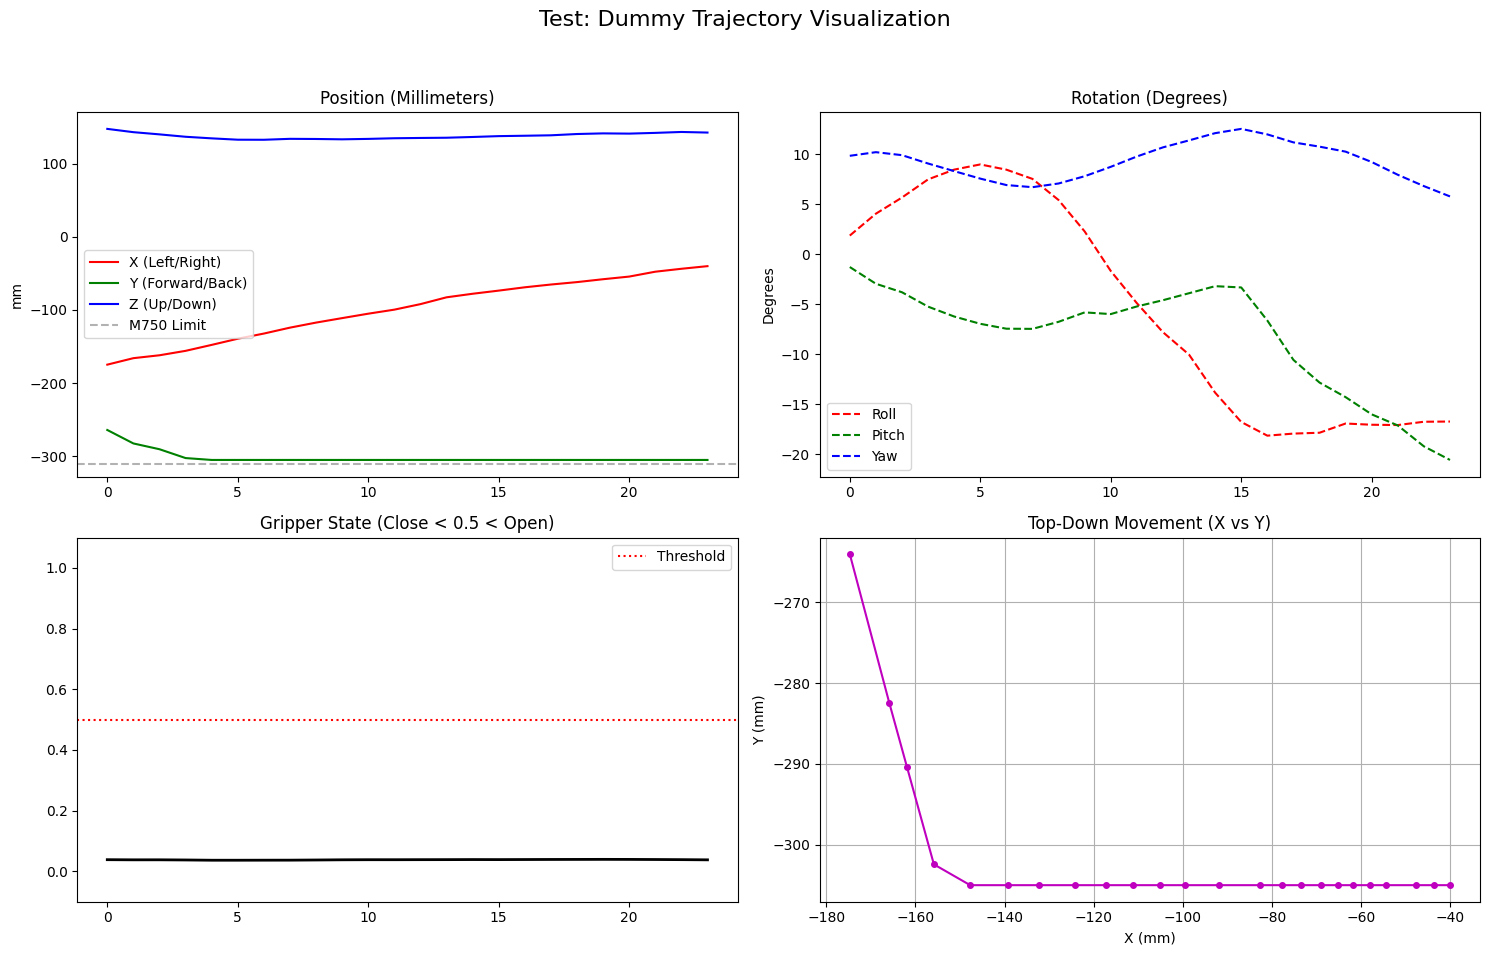

In [8]:
# 1. First, let's use the 'test_actions' we already generated in Cell 3/4
# This is the fastest way to see if your graphs look correct
m750_cmds = actions_to_m750_commands(test_actions)
visualize_m750_trajectory(m750_cmds, title="Test: Dummy Trajectory Visualization")

# 2. Or, if you want to test a REAL image:
# (Make sure you have a file named 'test_snapshot.jpg' in your folder)
# actions, cmds = predict_single_action('test_snapshot.jpg', 'pick up the marker')
# visualize_m750_trajectory(cmds, title="Inference on Real Image")

In [9]:
import os
import time
import torch
import numpy as np
import tarfile
import io
from PIL import Image

print("=" * 60)
print("🔍 OFFICIAL RDT2-M750 PRE-DEPLOYMENT INSPECTOR")
print("=" * 60)

# ── 1. DATASET INTEGRITY CHECK ───────────────────────────────
# Checks if the data you trained on matches the math in your code
print("\n1️⃣ Checking Training Data Format...")
sample_shard = f"{BASE_DIR}/shards_marker_only/shard-000000.tar"

if os.path.exists(sample_shard):
    try:
        with tarfile.open(sample_shard, 'r') as tar:
            # UMI shards usually name action files as '000000.action.npy'
            member = next(m for m in tar.getmembers() if ".action.npy" in m.name)
            f = tar.extractfile(member)
            action_sample = np.load(io.BytesIO(f.read()))
            
            # Check rotation (indices 3:6)
            max_rot = np.abs(action_sample[:, 3:6]).max()
            print(f"   Detected max rotation value: {max_rot:.4f}")
            
            if max_rot < 3.5:
                print("   ✅ SUCCESS: Dataset uses Axis-Angle (Radians). Math is aligned.")
            else:
                print("   ⚠️ WARNING: Dataset values are large. Check if you trained in Degrees.")
    except Exception as e:
        print(f"   ⚠️ Could not parse shard: {e}")
else:
    print(f"   ℹ️ Shard not found at {sample_shard}. Skipping data check.")

# ── 2. GPU STRESS & LATENCY TEST ─────────────────────────────
# Checks if your RTX 4090 is ready for real-time 5Hz-10Hz control
print("\n2️⃣ Benchmarking Inference Speed (10 iterations)...")
dummy_img = Image.new('RGB', (384, 384), color=(128, 128, 128))
latencies = []

for i in range(11): # 1 warmup + 10 timed
    t_start = time.time()
    # Execute the actual prediction function
    _ = batch_predict_action(
        model=model, processor=processor, vae=vae, normalizer=normalizer,
        images=dummy_img, instruction="pick up the marker", verbose=False
    )
    if i > 0: # Skip the first "warmup" run
        latencies.append(time.time() - t_start)

avg_ms = np.mean(latencies) * 1000
hz = 1.0 / np.mean(latencies)

print(f"   Average Latency: {avg_ms:.1f} ms")
print(f"   Max Thinking Rate: {hz:.2f} Hz")

if hz >= 5.0:
    print(f"   ✅ SUCCESS: System can handle 5Hz real-time control.")
else:
    print(f"   ⚠️ CAUTION: AI is slow ({hz:.1f}Hz). Set loop_rate_hz to 3.")

# ── 3. RESOURCE CHECK ────────────────────────────────────────
print("\n3️⃣ Checking GPU VRAM...")
if torch.cuda.is_available():
    used_vram = torch.cuda.memory_allocated(0) / 1e9
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   VRAM: {used_vram:.1f}GB used / {total_vram:.1f}GB total")
    if used_vram > 22:
        print("   ⚠️ CRITICAL: VRAM nearly full. Restart kernel to avoid crash.")
    else:
        print("   ✅ SUCCESS: VRAM is stable.")

print("\n" + "=" * 60)
print("🏁 VERIFICATION COMPLETE: Ready for M750 Deployment")
print("=" * 60)

🔍 OFFICIAL RDT2-M750 PRE-DEPLOYMENT INSPECTOR

1️⃣ Checking Training Data Format...
   Detected max rotation value: 2.3896
   ✅ SUCCESS: Dataset uses Axis-Angle (Radians). Math is aligned.

2️⃣ Benchmarking Inference Speed (10 iterations)...


/home/rishabh/Downloads/umi-pipeline-training/umi_env/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:631: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `1e-06` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


   Average Latency: 616.8 ms
   Max Thinking Rate: 1.62 Hz
   ⚠️ CAUTION: AI is slow (1.6Hz). Set loop_rate_hz to 3.

3️⃣ Checking GPU VRAM...
   VRAM: 18.3GB used / 25.3GB total
   ✅ SUCCESS: VRAM is stable.

🏁 VERIFICATION COMPLETE: Ready for M750 Deployment


In [10]:
from pymycobot.myarm import MyArm
import time

# 1. Setup Hardware Connection
# Ensure this matches your port (from terminal /dev/ttyACM1)
mc = MyArm("/dev/ttyACM1", 115200) 

print("🔄 Connecting and powering on...")
mc.power_on()
time.sleep(1)

# 2. Get the first command we calculated in Cell 4
# These are the numbers we verified: [-174.7, -264.0, 147.5]
first_move = m750_cmds[0]
target_coords = first_move['pos_mm'] + first_move['rot_deg']

print(f"🚀 Physically moving to: {np.round(first_move['pos_mm'], 1)}")

# 3. Send Move Command
# Speed 20, Mode 1 (Linear)
mc.send_coords(target_coords, 20, 1)

# 4. Handle Gripper
if first_move['gripper_open']:
    mc.set_gripper_state(0, 50)
else:
    mc.set_gripper_state(1, 50)

print("✅ Movement finished!")

🔄 Connecting and powering on...
🚀 Physically moving to: [-174.7 -264.   147.5]
✅ Movement finished!


In [11]:
from pymycobot.myarm import MyArm
import time

PORT = "/dev/ttyACM1" 

def test_connection(baud):
    print(f"🔄 Testing {baud} baud...")
    mc = MyArm(PORT, baud)
    time.sleep(1)
    res = mc.get_angles()
    if isinstance(res, list) and len(res) > 0:
        return mc, res
    return None, None

# Try 1,000,000 (Standard for M750)
mc, angles = test_connection(1000000)

if not mc:
    # Try 115,200 (Fallback)
    mc, angles = test_connection(115200)

if mc:
    print(f"✅ SUCCESS! Connected at {mc._baud} baud.")
    print(f"📍 Current Robot Angles: {angles}")
    print("⚡ Powering on servos...")
    mc.power_on()
    mc.set_fresh_mode(0) # Ensure it's in standard execution mode
    time.sleep(1)
else:
    print("❌ FAILED: Robot is not responding on ACM1 at any speed.")
    print("Check: 1. Is the green LED on? 2. Try ACM0 instead of ACM1.")

🔄 Testing 1000000 baud...
🔄 Testing 115200 baud...
❌ FAILED: Robot is not responding on ACM1 at any speed.
Check: 1. Is the green LED on? 2. Try ACM0 instead of ACM1.


In [12]:
# Assuming 'mc' is already connected from the cell above
if mc:
    # 1. Wake up the controller logic
    mc.set_fresh_mode(0) 
    mc.power_on()
    time.sleep(1)

    # 2. Coordinates from your successful Cell 4
    # XYZ: [-174.7, -264.0, 147.5] | ROT: [-2.99, 1.3, 10.57]
    target = [-174.7, -264.0, 147.5, -2.99, 1.3, 10.57]
    
    print(f"🚀 Moving to {target[:3]} at Speed 20...")
    
    # Send Move command
    mc.send_coords(target, 20, 1)
    
    # 3. VERIFICATION: Wait 2 seconds and check if coords changed
    time.sleep(2)
    new_coords = mc.get_coords()
    print(f"📍 New Position on Robot: {new_coords}")
    
    if new_coords and abs(new_coords[0] - target[0]) < 5:
        print("🎉 THE ROBOT PHYSICALLY MOVED!")
    else:
        print("😟 Command sent, but robot position didn't change.")